# 04 — Analisi dello spazio latente del VAE

In questo notebook viene analizzata la struttura dello spazio latente dei modelli VAE ottenuti per diversi valori di β.

Per ciascun modello vengono studiati il contributo KL delle singole dimensioni, il numero di dimensioni attive, la dimensionalità effettiva, la deviazione standard del posterior e il valore medio assoluto di μ.

L’obiettivo è comprendere come la riduzione del Rate osservata nell’analisi Rate–Distortion si rifletta sulla rappresentazione latente e come queste variazioni siano associate allo stochasticity gap.

Non vengono addestrati nuovi modelli: vengono utilizzati i checkpoint già ottenuti.

## 1. Librerie e configurazione

In [20]:
from pathlib import Path
import wave as waveio

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchaudio

from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42

SAMPLE_RATE = 8000
N_SAMPLES = 8000
N_FFT = 256
HOP_LENGTH = 64
SPEC_H = 128
SPEC_W = 128

LATENT_DIM = 128
BATCH_SIZE = 64

NOISE_STD = 0.05
PADDING_WEIGHT = 0.10

# Soglia operativa, non universale:
# una dimensione è detta "attiva" se il suo KL medio > 0.01 nats
ACTIVE_THRESHOLD = 0.01

CHECKPOINT_DIR = Path("checkpoints")
RESULTS_DIR = Path("results")

torch.manual_seed(SEED)
np.random.seed(SEED)

print("device:", device)
print("latent dim:", LATENT_DIM)
print("active threshold:", ACTIVE_THRESHOLD)


device: cpu
latent dim: 128
active threshold: 0.01


## 2. Preparazione del dataset e rappresentazione STFT

In [21]:
recordings_dir = Path("audio_data/free-spoken-digit-dataset-1.0.10/recordings")
wav_files = sorted(recordings_dir.glob("*.wav"))

if len(wav_files) == 0:
    raise FileNotFoundError("Dataset FSDD non trovato.")

def parse_name(path):
    digit, speaker, index = path.stem.split("_")
    return int(digit), speaker, int(index)

def load_fixed_audio(path):
    with waveio.open(str(path), "rb") as f:
        sr = f.getframerate()
        channels = f.getnchannels()
        frames = f.readframes(f.getnframes())

    audio = np.frombuffer(frames, dtype=np.int16).astype(np.float32) / 32768.0

    if channels > 1:
        audio = audio.reshape(-1, channels).mean(axis=1)

    waveform = torch.tensor(audio).unsqueeze(0)

    if sr != SAMPLE_RATE:
        waveform = torchaudio.functional.resample(
            waveform, sr, SAMPLE_RATE
        )

    valid_length = min(waveform.shape[1], N_SAMPLES)

    if waveform.shape[1] < N_SAMPLES:
        waveform = F.pad(
            waveform,
            (0, N_SAMPLES - waveform.shape[1])
        )
    else:
        waveform = waveform[:, :N_SAMPLES]

    mask = torch.zeros_like(waveform)
    mask[:, :valid_length] = 1.0

    return waveform, mask, valid_length

train_files = []
test_files = []

for path in wav_files:
    _, _, idx = parse_name(path)
    if idx <= 4:
        test_files.append(path)
    else:
        train_files.append(path)

window = torch.hann_window(N_FFT)

def stft_complex(x):
    return torch.stft(
        x.squeeze(0),
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=N_FFT,
        window=window,
        return_complex=True
    )

def crop_logmag(logmag):
    logmag = logmag[:SPEC_H, :]

    if logmag.shape[1] < SPEC_W:
        logmag = F.pad(
            logmag,
            (0, SPEC_W - logmag.shape[1])
        )
    else:
        logmag = logmag[:, :SPEC_W]

    return logmag

print("Train:", len(train_files))
print("Test :", len(test_files))


Train: 2700
Test : 300


## 3. Normalizzazione delle rappresentazioni spettrali

In [8]:
sum_x = 0.0
sum_x2 = 0.0
count_values = 0

for path in train_files:
    clean, _, _ = load_fixed_audio(path)

    X = stft_complex(clean)
    logmag = crop_logmag(torch.log1p(X.abs()))

    sum_x += logmag.sum().item()
    sum_x2 += (logmag ** 2).sum().item()
    count_values += logmag.numel()

SPEC_MEAN = sum_x / count_values

variance = (
    sum_x2 / count_values
    - SPEC_MEAN ** 2
)

SPEC_STD = max(variance, 1e-8) ** 0.5

print("SPEC_MEAN:", SPEC_MEAN)
print("SPEC_STD :", SPEC_STD)


SPEC_MEAN: 0.04547776059049216
SPEC_STD : 0.16703430628401916


## 4. Costruzione del test set


In [9]:
class LatentDataset(Dataset):
    def __init__(self, files):
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        clean, mask, _ = load_fixed_audio(self.files[i])

        g = torch.Generator().manual_seed(10000 + i)
        noise = torch.randn(clean.shape, generator=g)

        noisy = torch.clamp(
            clean + NOISE_STD * noise * mask,
            -1.0,
            1.0
        )

        noisy_stft = stft_complex(noisy)

        noisy_logmag = crop_logmag(
            torch.log1p(noisy_stft.abs())
        )

        noisy_img = (
            (noisy_logmag - SPEC_MEAN)
            / SPEC_STD
        ).unsqueeze(0)

        digit, _, _ = parse_name(self.files[i])

        return noisy_img, digit

test_loader = DataLoader(
    LatentDataset(test_files),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Test dataset pronto")


Test dataset pronto


In [ ]:
class STFTVAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU()
        )

        self.fc_mu = nn.Linear(
            128 * 16 * 16,
            LATENT_DIM
        )

        self.fc_logvar = nn.Linear(
            128 * 16 * 16,
            LATENT_DIM
        )

        self.fc_decode = nn.Linear(
            LATENT_DIM,
            128 * 16 * 16
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1)
        )

    def encode(self, x):
        h = self.encoder(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)

    def decode(self, z):
        h = self.fc_decode(z).view(-1, 128, 16, 16)
        return self.decoder(h)


CHECKPOINTS = {
    0.0: CHECKPOINT_DIR / "vae_beta_0e+00.pt",
    1e-6: CHECKPOINT_DIR / "vae_beta_1em06.pt",
    3e-6: CHECKPOINT_DIR / "vae_beta_3em06.pt",
    1e-5: CHECKPOINT_DIR / "vae_beta_1em05.pt",
    3e-5: CHECKPOINT_DIR / "vae_beta_3em05.pt",
    1e-4: CHECKPOINT_DIR / "vae_beta_1em04.pt",
    3e-4: CHECKPOINT_DIR / "vae_beta_3em04.pt",
    1e-3: CHECKPOINT_DIR / "vae_beta_1em03.pt",
    3e-3: CHECKPOINT_DIR / "vae_beta_3em03.pt",
    1e-2: CHECKPOINT_DIR / "vae_beta_1em02.pt"
}

missing = [
    path
    for path in CHECKPOINTS.values()
    if not Path(path).exists()
]

if missing:
    print("Checkpoint mancanti:")
    for path in missing:
        print(" -", path)
    raise FileNotFoundError("Mancano alcuni checkpoint.")

print("Checkpoint trovati:", len(CHECKPOINTS))


Checkpoint trovati: 10


## 6. Analisi delle statistiche dello spazio latente

Per ciascun modello vengono calcolate statistiche che descrivono come l’informazione è distribuita nello spazio latente.

Una dimensione viene considerata attiva quando il suo contributo KL medio supera 0.01 nats. Questa soglia viene utilizzata esclusivamente come criterio operativo e non rappresenta una soglia universale.

Viene inoltre calcolata la dimensionalità effettiva, che misura quanto uniformemente il Rate complessivo è distribuito tra le dimensioni latenti.

Se il Rate è distribuito su molte dimensioni in modo relativamente uniforme, la dimensionalità effettiva assume valori elevati. Se invece l’informazione è concentrata in poche dimensioni, il valore diminuisce.


In [11]:
def latent_statistics(checkpoint_path):
    model = STFTVAE().to(device)

    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location=device
        )
    )

    model.eval()

    kl_sum = torch.zeros(
        LATENT_DIM,
        device=device
    )

    sigma_sum = torch.zeros(
        LATENT_DIM,
        device=device
    )

    mu_abs_sum = torch.zeros(
        LATENT_DIM,
        device=device
    )

    count = 0

    with torch.no_grad():
        for noisy_img, _ in test_loader:
            noisy_img = noisy_img.to(device)

            mu, logvar = model.encode(noisy_img)

            kl_dim = -0.5 * (
                1
                + logvar
                - mu.pow(2)
                - logvar.exp()
            )

            sigma = torch.exp(
                0.5 * logvar
            )

            kl_sum += kl_dim.sum(dim=0)
            sigma_sum += sigma.sum(dim=0)
            mu_abs_sum += mu.abs().sum(dim=0)

            count += noisy_img.size(0)

    mean_kl = (
        kl_sum / count
    ).cpu().numpy()

    mean_sigma = (
        sigma_sum / count
    ).cpu().numpy()

    mean_abs_mu = (
        mu_abs_sum / count
    ).cpu().numpy()

    rate = mean_kl.sum()

    active_dims = int(
        np.sum(
            mean_kl > ACTIVE_THRESHOLD
        )
    )

    denom = np.sum(
        mean_kl ** 2
    )

    effective_dims = (
        rate ** 2 / denom
        if denom > 0
        else 0.0
    )

    return {
        "Rate": float(rate),
        "ActiveDims": active_dims,
        "EffectiveDims": float(effective_dims),
        "MeanSigma": float(mean_sigma.mean()),
        "MedianSigma": float(np.median(mean_sigma)),
        "MeanAbsMu": float(mean_abs_mu.mean()),
        "KL_per_dim": mean_kl,
        "Sigma_per_dim": mean_sigma
    }


latent_results = []
kl_matrix = []
sigma_matrix = []

for beta, path in CHECKPOINTS.items():
    print(f"Analizzo beta = {beta:.0e}")

    stats = latent_statistics(path)

    latent_results.append(
        {
            "beta": beta,
            "Rate": stats["Rate"],
            "ActiveDims": stats["ActiveDims"],
            "EffectiveDims": stats["EffectiveDims"],
            "MeanSigma": stats["MeanSigma"],
            "MedianSigma": stats["MedianSigma"],
            "MeanAbsMu": stats["MeanAbsMu"]
        }
    )

    kl_matrix.append(
        stats["KL_per_dim"]
    )

    sigma_matrix.append(
        stats["Sigma_per_dim"]
    )

latent_df = pd.DataFrame(
    latent_results
).sort_values("beta")

kl_matrix = np.array(kl_matrix)
sigma_matrix = np.array(sigma_matrix)

latent_df


Analizzo beta = 0e+00
Analizzo beta = 1e-06
Analizzo beta = 3e-06
Analizzo beta = 1e-05
Analizzo beta = 3e-05
Analizzo beta = 1e-04
Analizzo beta = 3e-04
Analizzo beta = 1e-03
Analizzo beta = 3e-03
Analizzo beta = 1e-02


,beta,Rate,ActiveDims,EffectiveDims,MeanSigma,MedianSigma,MeanAbsMu
0,0.000000,769.484497,128,123.195839,0.034960,0.034343,1.817319
1,0.000001,718.096252,128,122.595909,0.049454,0.049063,1.804432
2,0.000003,661.143188,128,121.987175,0.071917,0.071355,1.781488
3,0.000010,576.091125,128,121.558678,0.112898,0.112354,1.708482
4,0.000030,472.479248,128,121.834251,0.161956,0.161339,1.550678
5,0.000100,338.115967,128,122.811462,0.228585,0.228440,1.269212
6,0.000300,222.941864,128,123.366150,0.312865,0.313237,0.985213
7,0.001000,122.492577,128,121.376526,0.465426,0.463980,0.746709
8,0.003000,67.326279,128,118.357582,0.615674,0.614776,0.586832
9,0.010000,33.735149,128,114.967949,0.771047,0.777139,0.451426


## 7.  Distribuzione del KL nelle dimensioni latenti

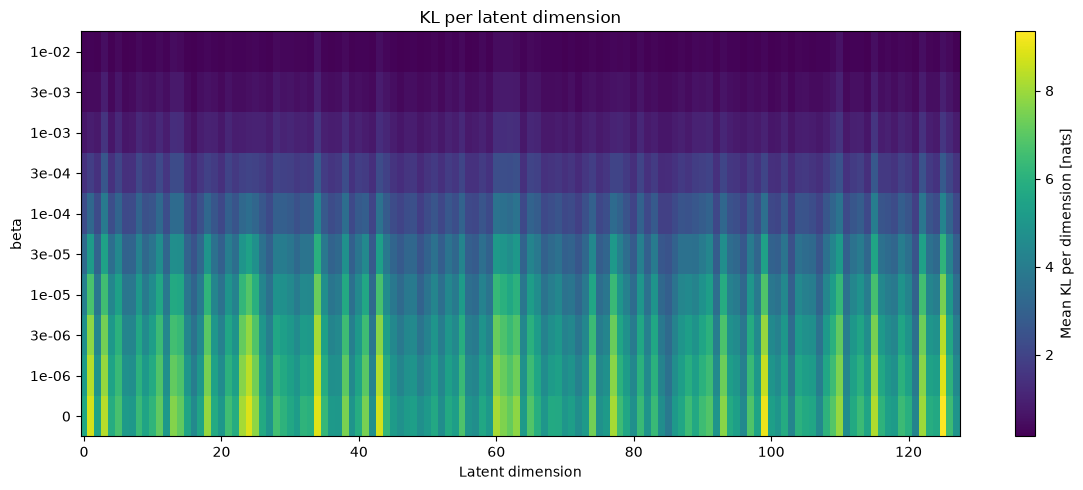

In [12]:
beta_labels = [
    "0" if b == 0 else f"{b:.0e}"
    for b in CHECKPOINTS.keys()
]

plt.figure(figsize=(12, 5))

plt.imshow(
    kl_matrix,
    aspect="auto",
    origin="lower"
)

plt.colorbar(
    label="Mean KL per dimension [nats]"
)

plt.yticks(
    range(len(beta_labels)),
    beta_labels
)

plt.xlabel("Latent dimension")
plt.ylabel("beta")
plt.title("KL per latent dimension")
plt.tight_layout()
plt.show()


## 8. Dimensioni latenti attive ed effettive

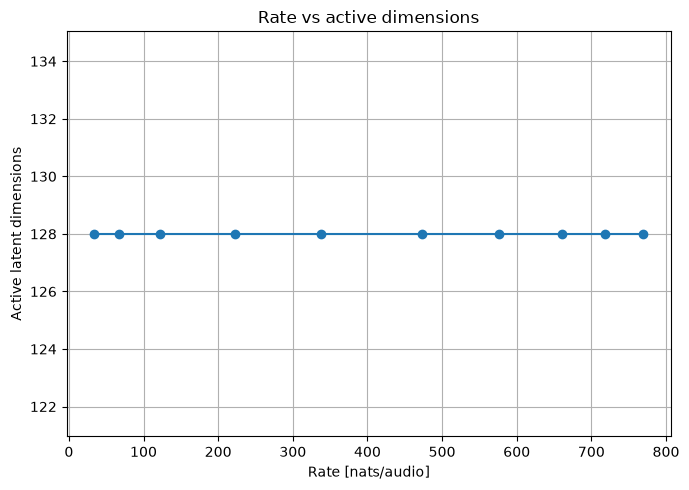

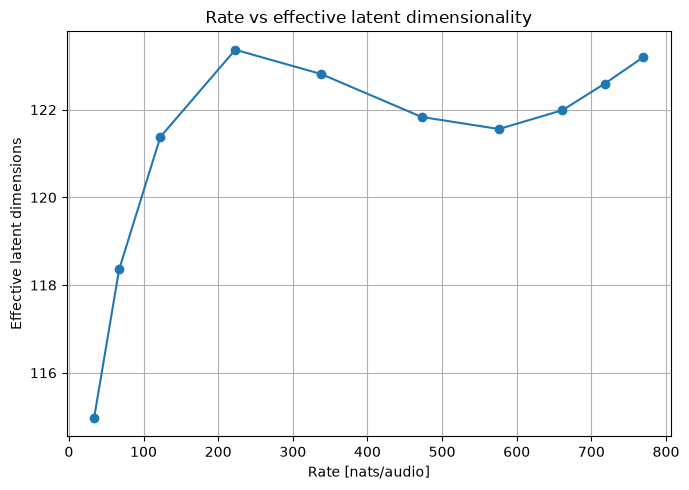

In [13]:
plot_df = latent_df.sort_values("Rate")

plt.figure(figsize=(7, 5))

plt.plot(
    plot_df["Rate"],
    plot_df["ActiveDims"],
    marker="o"
)

plt.xlabel("Rate [nats/audio]")
plt.ylabel("Active latent dimensions")
plt.title("Rate vs active dimensions")
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 5))

plt.plot(
    plot_df["Rate"],
    plot_df["EffectiveDims"],
    marker="o"
)

plt.xlabel("Rate [nats/audio]")
plt.ylabel("Effective latent dimensions")
plt.title("Rate vs effective latent dimensionality")
plt.grid(True)
plt.tight_layout()
plt.show()


## 9. Comportamento della deviazione standard del posterior

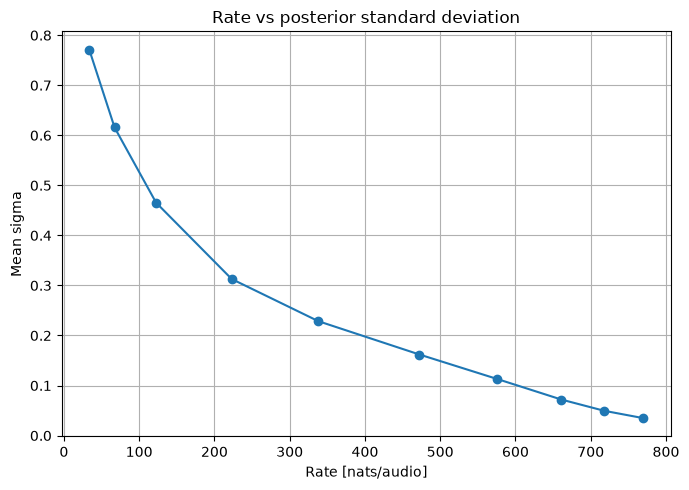

In [14]:
plt.figure(figsize=(7, 5))

plt.plot(
    plot_df["Rate"],
    plot_df["MeanSigma"],
    marker="o"
)

plt.xlabel("Rate [nats/audio]")
plt.ylabel("Mean sigma")
plt.title("Rate vs posterior standard deviation")
plt.grid(True)
plt.tight_layout()
plt.show()


## 10. Distribuzione di σ nelle dimensioni latenti

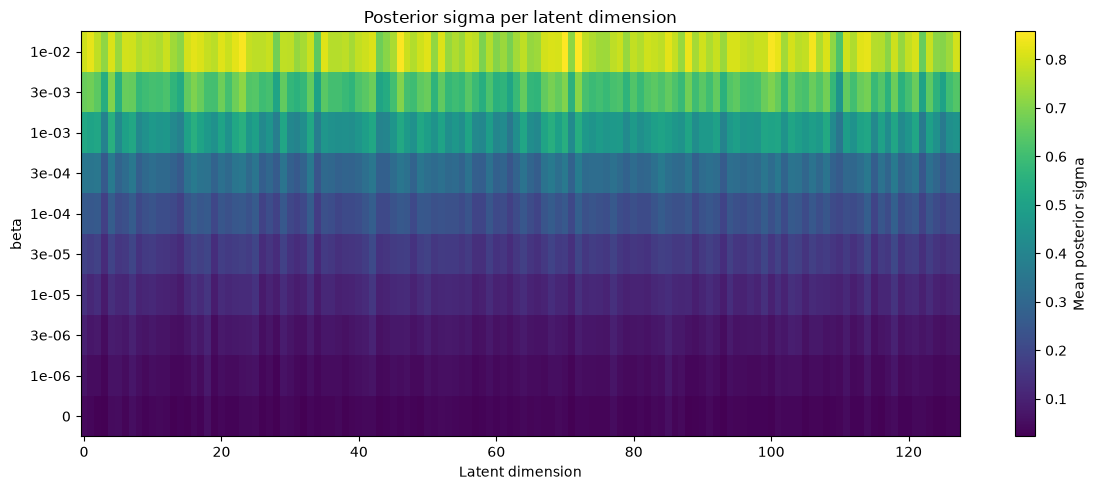

In [15]:
plt.figure(figsize=(12, 5))

plt.imshow(
    sigma_matrix,
    aspect="auto",
    origin="lower"
)

plt.colorbar(
    label="Mean posterior sigma"
)

plt.yticks(
    range(len(beta_labels)),
    beta_labels
)

plt.xlabel("Latent dimension")
plt.ylabel("beta")
plt.title("Posterior sigma per latent dimension")
plt.tight_layout()
plt.show()


## 11. Relazione tra spazio latente e stochasticity gap


Per i quattro valori di β più rappresentativi vengono confrontate le statistiche dello spazio latente con lo stochasticity gap ottenuto nell’analisi precedente.

Lo stochasticity gap è definito come:

G_stoch = D_sample - D_mu

dove D_mu rappresenta la distorsione della ricostruzione deterministica ottenuta con z = μ, mentre D_sample rappresenta la distorsione media ottenuta campionando dal posterior.

L’obiettivo è verificare se l’aumento dell’incertezza del posterior sia associato a una maggiore sensibilità della ricostruzione alla componente stocastica.


In [16]:
metrics_csv = RESULTS_DIR / "audio_metrics_sampling.csv"

mc_csv = RESULTS_DIR / "rate_distortion_sampling.csv"

if not metrics_csv.exists():
    raise FileNotFoundError(
        "Non trovo results/audio_metrics_sampling.csv"
    )

if not mc_csv.exists():
    raise FileNotFoundError(
        "Non trovo results/rate_distortion_sampling.csv"
    )

metrics_df = pd.read_csv(
    metrics_csv
)

mc_df = pd.read_csv(
    mc_csv
)

selected_latent = latent_df[
    latent_df["beta"].isin(
        [1e-4, 3e-4, 1e-3, 1e-2]
    )
].copy()

gap_df = mc_df.copy()

gap_df["StochasticityGap"] = (
    gap_df["D_sample"]
    - gap_df["D_mu"]
)

combined_df = selected_latent.merge(
    gap_df[
        [
            "beta",
            "D_mu",
            "D_sample",
            "StochasticityGap"
        ]
    ],
    on="beta",
    how="left"
)

combined_df


,beta,Rate,ActiveDims,EffectiveDims,MeanSigma,MedianSigma,MeanAbsMu,D_mu,D_sample,StochasticityGap
0,0.0001,338.115967,128,122.811462,0.228585,0.228440,1.269212,0.249429,0.253544,0.004115
1,0.0003,222.941864,128,123.366150,0.312865,0.313237,0.985213,0.252140,0.264340,0.012199
2,0.0010,122.492577,128,121.376526,0.465426,0.463980,0.746709,0.259144,0.298230,0.039086
3,0.0100,33.735149,128,114.967949,0.771047,0.777139,0.451426,0.322007,0.491691,0.169684


## 12. Stochasticity gap e deviazione standard del posterior

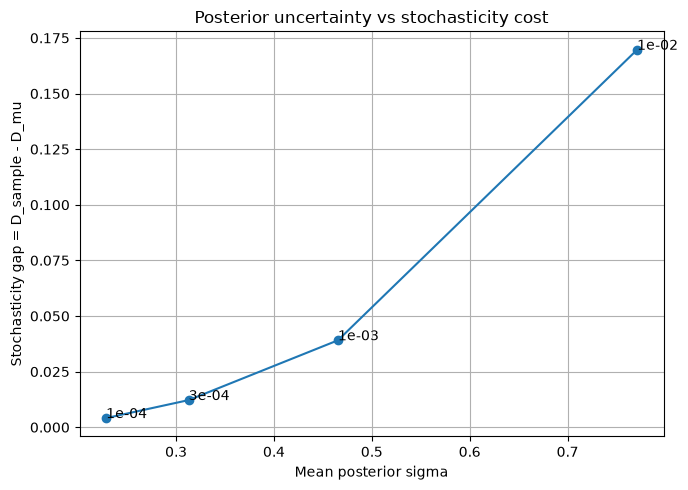

In [17]:
plt.figure(figsize=(7, 5))

plt.plot(
    combined_df["MeanSigma"],
    combined_df["StochasticityGap"],
    marker="o"
)

for _, row in combined_df.iterrows():
    plt.annotate(
        f'{row["beta"]:.0e}',
        (
            row["MeanSigma"],
            row["StochasticityGap"]
        )
    )

plt.xlabel("Mean posterior sigma")
plt.ylabel(
    "Stochasticity gap = D_sample - D_mu"
)

plt.title(
    "Posterior uncertainty vs stochasticity cost"
)

plt.grid(True)
plt.tight_layout()
plt.show()


## 13.  Stochasticity gap e dimensionalità latente effettiva

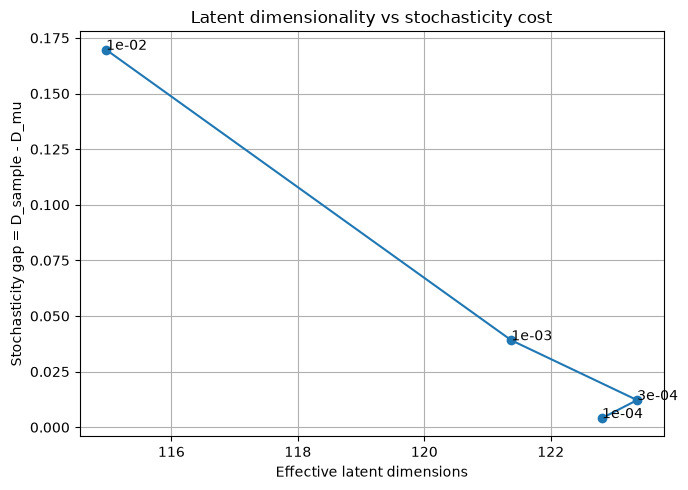

In [18]:
plt.figure(figsize=(7, 5))

plt.plot(
    combined_df["EffectiveDims"],
    combined_df["StochasticityGap"],
    marker="o"
)

for _, row in combined_df.iterrows():
    plt.annotate(
        f'{row["beta"]:.0e}',
        (
            row["EffectiveDims"],
            row["StochasticityGap"]
        )
    )

plt.xlabel("Effective latent dimensions")
plt.ylabel(
    "Stochasticity gap = D_sample - D_mu"
)

plt.title(
    "Latent dimensionality vs stochasticity cost"
)

plt.grid(True)
plt.tight_layout()
plt.show()


## 14. Salvataggio dei risultati

In [19]:
latent_df.to_csv(
    RESULTS_DIR / "latent_summary.csv",
    index=False
)

combined_df.to_csv(
    RESULTS_DIR / "latent_vs_stochasticity.csv",
    index=False
)

np.save(
    RESULTS_DIR / "kl_per_dimension.npy",
    kl_matrix
)

np.save(
    RESULTS_DIR / "sigma_per_dimension.npy",
    sigma_matrix
)

print("Salvati:")
print(" - step11_latent_summary.csv")
print(" - step11_latent_vs_stochasticity.csv")
print(" - step11_kl_per_dimension.npy")
print(" - step11_sigma_per_dimension.npy")


Salvati:
 - step11_latent_summary.csv
 - step11_latent_vs_stochasticity.csv
 - step11_kl_per_dimension.npy
 - step11_sigma_per_dimension.npy


# Interpretazione finale dei risultati

L’analisi dello spazio latente mostra che la diminuzione del Rate non è accompagnata da una disattivazione delle dimensioni latenti: secondo la soglia operativa adottata, tutte le 128 dimensioni rimangono attive nei modelli considerati.

La dimensionalità effettiva varia in misura relativamente contenuta, indicando che la riduzione del Rate è principalmente associata a una diminuzione diffusa del contributo informativo delle dimensioni latenti, piuttosto che alla loro completa eliminazione.

Al diminuire del Rate, la deviazione standard media del posterior aumenta progressivamente, mentre il valore medio assoluto di μ diminuisce. Questo comportamento è coerente con un posterior che si avvicina progressivamente al prior.

Nei quattro modelli analizzati in dettaglio emerge inoltre una forte associazione tra l’aumento di σ e la crescita dello stochasticity gap. I modelli caratterizzati da maggiore incertezza latente risultano quindi anche più sensibili alla variabilità introdotta dal sampling.

La variazione della dimensionalità effettiva non presenta invece un andamento strettamente monotono rispetto allo stochasticity gap. I risultati suggeriscono quindi che l’aumento della variabilità del posterior costituisca un indicatore più diretto della crescente sensibilità stocastica osservata nelle ricostruzioni.